# Loading and setting up the data

In [ ]:
from google.colab import drive
import h5py
import numpy as np
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_path = '/content/drive/MyDrive/Astro Projects/Galaxy morphology/data/Galaxy10_DECals.h5'
local_path = '/content/Galaxy10_DECals.h5'

if not os.path.exists(local_path):
    print("Copying dataset to local VM disk...")
    !cp "{drive_path}" "{local_path}"
    print("Transfer complete.")

print("Loading dataset into RAM safely...")
with h5py.File(local_path, 'r') as f:
    # Load as uint8 (0-255) -> Only consumes ~3.5 GB of RAM!
    images = np.array(f['images'], dtype=np.uint8)
    labels = np.array(f['ans'], dtype=np.int64)

print(f"Loaded successfully!")
print(f"Images Shape: {images.shape} | Data Type: {images.dtype}")
print(f"Memory used by images array: {images.nbytes / (1024**3):.2f} GB")

Copying dataset to local VM disk...
Transfer complete.
Loading dataset into RAM safely...
Loaded successfully!
Images Shape: (17736, 256, 256, 3) | Data Type: uint8
Memory used by images array: 3.25 GB


# Custom mapping

In [ ]:
label_mapping = {
    0: 0,  # Disturbed → Disturbed
    1: 1,  # Merging → Merging
    2: 2,  # Round Smooth → Elliptical
    3: 2,  # In-between Round Smooth → Elliptical
    4: 2,  # Cigar Shaped Smooth → Elliptical
    5: 3,  # Barred Spiral → Barred Spiral
    6: 4,  # Unbarred Tight Spiral → Unbarred Spiral
    7: 4,  # Unbarred Loose Spiral → Unbarred Spiral
    8: 5,  # Edge-on without Bulge → Edge-on
    9: 5   # Edge-on with Bulge → Edge-on
}

y_6class = np.array([label_mapping[label] for label in labels])

class_names = [
    "Disturbed",
    "Merging",
    "Elliptical",
    "Barred Spiral",
    "Unbarred Spiral",
    "Edge-on"
]

In [ ]:
unique, counts = np.unique(y_6class, return_counts=True)

for i, count in zip(unique, counts):
    print(f"Class {i} ({count}): {class_names[i]}")

Class 0 (1081): Disturbed
Class 1 (1853): Merging
Class 2 (5006): Elliptical
Class 3 (2043): Barred Spiral
Class 4 (4457): Unbarred Spiral
Class 5 (3296): Edge-on


# Data Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
indices=np.arange(len(images))

train_idx,val_idx,y_train,y_val=train_test_split(indices,y_6class,test_size=0.2,stratify=labels,random_state=42)

In [ ]:
print(f"Training set:   {len(train_idx)} samples")
print(f"Validation set: {len(val_idx)} samples")

Training set:   14188 samples
Validation set: 3548 samples


# Data Pipeline and Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size=32
target_size=(224,224)

In [ ]:
def data_generator(indices,image_array,label_array):

  for idx in indices:
    yield image_array[idx].astype(np.float32),label_array[idx]

In [ ]:
def preprocess(image,label):

  image=tf.image.resize(image,target_size)

  return image,label

In [ ]:

def create_pipeline(indices, is_training=True):
    ds = tf.data.Dataset.from_generator(
        lambda: data_generator(indices, images, y_6class),
        output_signature=(
            tf.TensorSpec(shape=images.shape[1:], dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 1000))

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    if is_training:
      ds=ds.repeat()

    ds=ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_dataset = create_pipeline(train_idx, is_training=True)
val_dataset = create_pipeline(val_idx, is_training=False)

# Creating the Model

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0  # Switched to EfficientNetB0

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(6, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs, name='Galaxy10_EfficientNetB0')

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Galaxy10_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print('Model successfully compiled for training')

Model successfully compiled for training


In [ ]:
from tensorflow.keras import callbacks

early_stopping=callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint=callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr=callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

cb_list=[early_stopping,model_checkpoint,reduce_lr]

# Model Training (Phase 1)

In [ ]:
steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5668 - loss: 1.1933
Epoch 1: val_loss improved from None to 0.98470, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1271s 3s/step - accuracy: 0.6056 - loss: 1.0870 - val_accuracy: 0.6437 - val_loss: 0.9847 - learning_rate: 0.0010
Epoch 2/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6429 - loss: 0.9852
Epoch 2: val_loss improved from 0.98470 to 0.90539, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1343s 3s/step - accuracy: 0.6489 - loss: 0.9676 - v

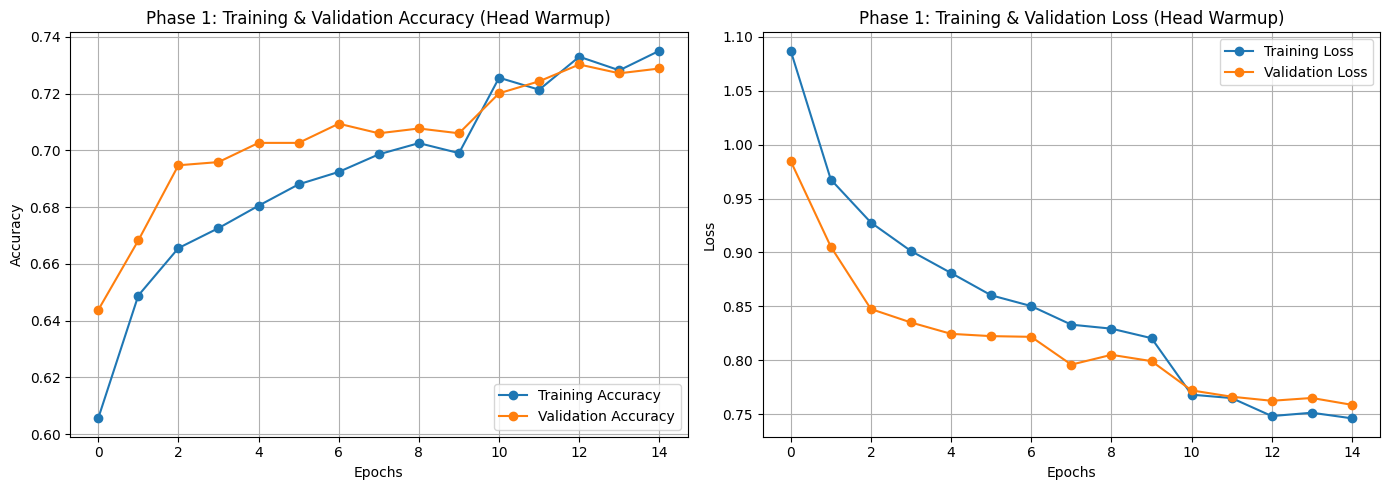

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot( history_phase1.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 1: Training & Validation Accuracy (Head Warmup)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot( history_phase1.history['loss'], label='Training Loss', marker='o')
plt.plot( history_phase1.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 1: Training & Validation Loss (Head Warmup)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/phase1_performance.png', bbox_inches='tight')
plt.show()

# Model Training (Phase 2)

In [ ]:
import tensorflow as tf

# Load Phase 1 saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase1.keras')

# Isolate base_model reference from loaded model
base_model = model.get_layer('efficientnetb0')

In [ ]:
# Unfreeze base model
base_model.trainable = True

# Keep lower layers frozen, unfreeze top ~40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# CRITICAL: Recompile with 1e-5 learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "Galaxy10_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 2,380,182 (9.08 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [ ]:
phase1_epochs = 15
total_epochs = phase1_epochs + 12

steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=total_epochs,
    initial_epoch=phase1_epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list
)

Epoch 16/27
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5591 - loss: 1.3939
Epoch 16: val_loss improved from None to 0.88740, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2.keras

Epoch 16: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1542s 3s/step - accuracy: 0.5941 - loss: 1.2295 - val_accuracy: 0.6936 - val_loss: 0.8874 - learning_rate: 1.0000e-05
Epoch 17/27
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6642 - loss: 0.9832
Epoch 17: val_loss improved from 0.88740 to 0.81976, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2.keras

Epoch 17: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1476s 3s/step - accuracy: 0.6672 - loss: 

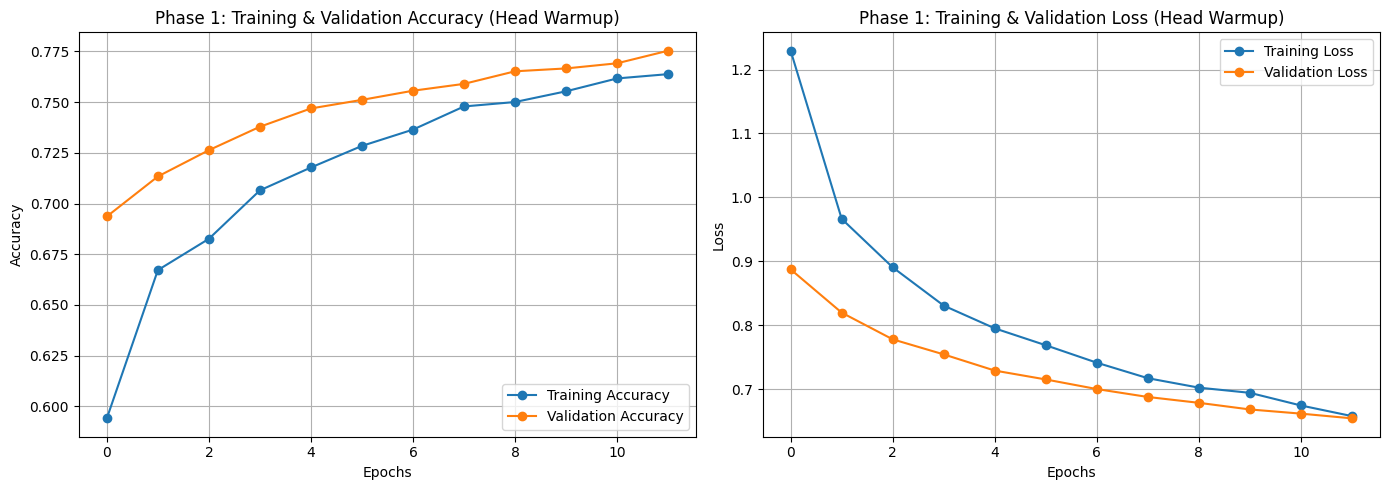

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase2.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot( history_phase2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 1: Training & Validation Accuracy (Head Warmup)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot( history_phase2.history['loss'], label='Training Loss', marker='o')
plt.plot( history_phase2.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 1: Training & Validation Loss (Head Warmup)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/phase2_performance.png', bbox_inches='tight')
plt.show()

# Model Training (Phase 2 Run 2)

In [ ]:
import tensorflow as tf

# Load Phase 1 saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2.keras')

# Isolate base_model reference from loaded model
base_model = model.get_layer('efficientnetb0')

In [ ]:
steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

history_phase2_run2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=37,
    initial_epoch=27,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list
)

Epoch 28/37
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7734 - loss: 0.6394
Epoch 28: val_loss improved from None to 0.64859, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run2.keras

Epoch 28: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1082s 2s/step - accuracy: 0.7711 - loss: 0.6442 - val_accuracy: 0.7779 - val_loss: 0.6486 - learning_rate: 1.0000e-05
Epoch 29/37
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7706 - loss: 0.6376
Epoch 29: val_loss improved from 0.64859 to 0.64562, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run2.keras

Epoch 29: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1118s 3s/step - accur

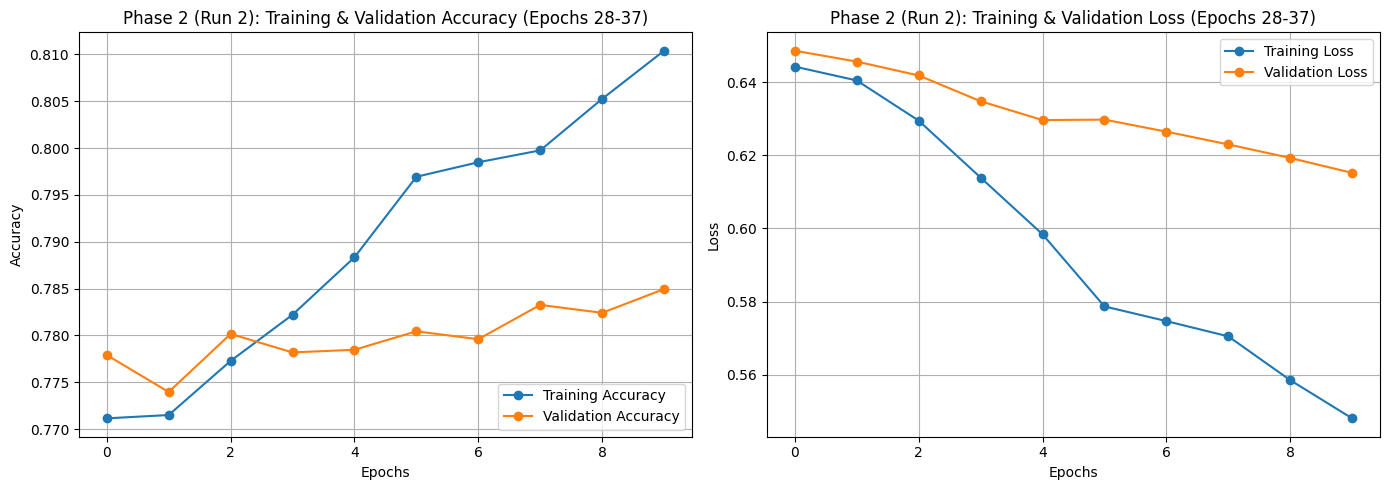

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase2_run2.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_phase2_run2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 2 (Run 2): Training & Validation Accuracy (Epochs 28-37)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history_phase2_run2.history['loss'], label='Training Loss', marker='o')
plt.plot(history_phase2_run2.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 2 (Run 2): Training & Validation Loss (Epochs 28-37)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/phase2_run2_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Model Training (Phase 3: Augemented)

In [ ]:
import tensorflow as tf

# Load Phase 1 saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run2.keras')

# Isolate base_model reference from loaded model
base_model = model.get_layer('efficientnetb0')

In [ ]:
steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

In [ ]:
from tensorflow.keras import models,layers

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=1.0),  # Full 360-degree rotational invariance
    layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
], name="spatial_augmentation")

train_dataset_augmented = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_phase3 = model.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=47,
    initial_epoch=37,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list
)

Epoch 38/47
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7526 - loss: 0.7205
Epoch 38: val_loss improved from None to 0.63014, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras

Epoch 38: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1187s 3s/step - accuracy: 0.7554 - loss: 0.7192 - val_accuracy: 0.7802 - val_loss: 0.6301 - learning_rate: 5.0000e-06
Epoch 39/47
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7658 - loss: 0.6782
Epoch 39: val_loss improved from 0.63014 to 0.63001, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras

Epoch 39: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1164s 3s/step - accuracy: 0.7611 - loss: 

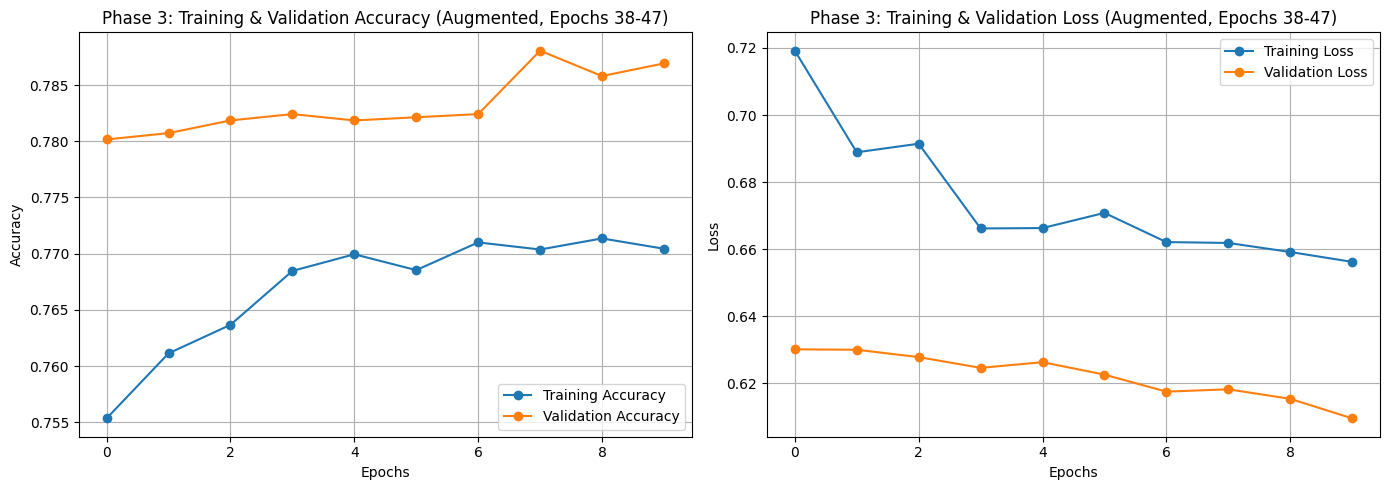

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase3.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_phase3.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 3: Training & Validation Accuracy (Augmented, Epochs 38-47)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history_phase3.history['loss'], label='Training Loss', marker='o')
plt.plot(history_phase3.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 3: Training & Validation Loss (Augmented, Epochs 38-47)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/phase3_augmented_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Master Plot depicting performance across all Epochs

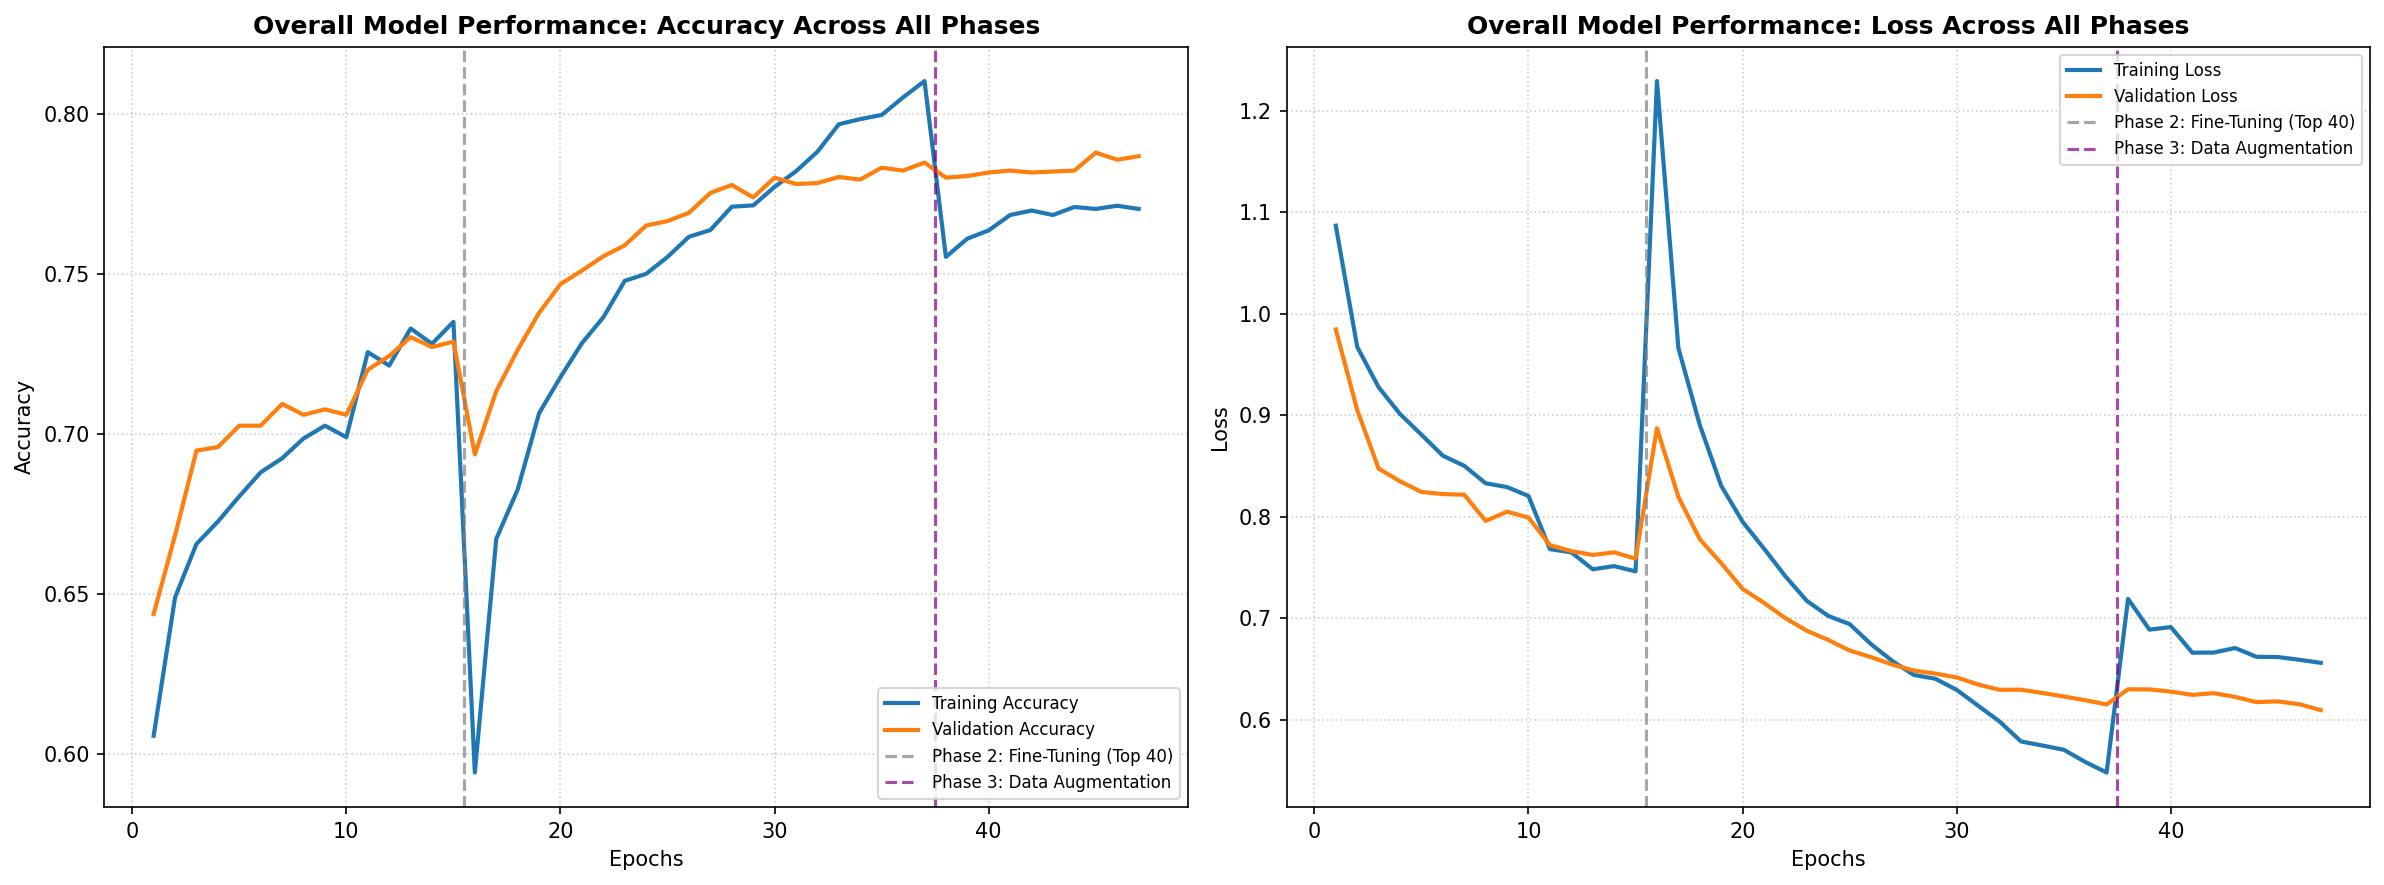

In [ ]:
import matplotlib.pyplot as plt


history = {
    'accuracy': [
        0.6056, 0.6489, 0.6656, 0.6726, 0.6805,
        0.6880, 0.6924, 0.6986, 0.7026, 0.6990,
        0.7256, 0.7214, 0.7330, 0.7282, 0.7351
    ],
    'val_accuracy': [
        0.6437, 0.6683, 0.6948, 0.6959, 0.7026,
        0.7026, 0.7094, 0.7060, 0.7077, 0.7060,
        0.7201, 0.7244, 0.7303, 0.7272, 0.7289
    ],
    'loss': [
        1.0870, 0.9676, 0.9278, 0.9014, 0.8810,
        0.8603, 0.8503, 0.8331, 0.8294, 0.8206,
        0.7682, 0.7651, 0.7484, 0.7515, 0.7463
    ],
    'val_loss': [
        0.9847, 0.9054, 0.8476, 0.8351, 0.8246,
        0.8225, 0.8218, 0.7960, 0.8052, 0.7993,
        0.7722, 0.7663, 0.7625, 0.7651, 0.7588
    ]
}

# Phase 2 Run 1: Epochs 16–27
history_phase2_run1 = {
    'accuracy': [
        0.5941, 0.6672, 0.6826, 0.7065, 0.7178, 0.7284,
        0.7365, 0.7479, 0.7501, 0.7554, 0.7617, 0.7638
    ],
    'val_accuracy': [
        0.6936, 0.7134, 0.7263, 0.7379, 0.7469, 0.7511,
        0.7556, 0.7590, 0.7652, 0.7666, 0.7692, 0.7754
    ],
    'loss': [
        1.2295, 0.9664, 0.8906, 0.8307, 0.7952, 0.7687,
        0.7414, 0.7172, 0.7024, 0.6943, 0.6745, 0.6579
    ],
    'val_loss': [
        0.8874, 0.8198, 0.7780, 0.7544, 0.7291, 0.7152,
        0.7002, 0.6878, 0.6787, 0.6683, 0.6618, 0.6544
    ]
}

# Phase 2 Run 2: Epochs 28–37
history_phase2_run2 = {
    'accuracy': [
        0.7711, 0.7715, 0.7773, 0.7822, 0.7883,
        0.7969, 0.7985, 0.7998, 0.8053, 0.8104
    ],
    'val_accuracy': [
        0.7779, 0.7740, 0.7802, 0.7782, 0.7785,
        0.7804, 0.7796, 0.7833, 0.7824, 0.7849
    ],
    'loss': [
        0.6442, 0.6405, 0.6295, 0.6139, 0.5984,
        0.5787, 0.5747, 0.5705, 0.5585, 0.5481
    ],
    'val_loss': [
        0.6486, 0.6456, 0.6418, 0.6348, 0.6296,
        0.6297, 0.6265, 0.6230, 0.6193, 0.6152
    ]
}

# Phase 3: Epochs 38–47
history_phase3 = {
    'accuracy': [
        0.7554, 0.7611, 0.7637, 0.7685, 0.7699,
        0.7685, 0.7710, 0.7704, 0.7714, 0.7704
    ],
    'val_accuracy': [
        0.7802, 0.7807, 0.7818, 0.7824, 0.7818,
        0.7821, 0.7824, 0.7880, 0.7858, 0.7869
    ],
    'loss': [
        0.7192, 0.6889, 0.6914, 0.6662, 0.6663,
        0.6708, 0.6621, 0.6619, 0.6592, 0.6562
    ],
    'val_loss': [
        0.6301, 0.6300, 0.6278, 0.6246, 0.6263,
        0.6226, 0.6175, 0.6182, 0.6154, 0.6096
    ]
}


# ==========================================
# MASTER PLOT
# ==========================================

full_accuracy = (
    history['accuracy'] +
    history_phase2_run1['accuracy'] +
    history_phase2_run2['accuracy'] +
    history_phase3['accuracy']
)

full_val_accuracy = (
    history['val_accuracy'] +
    history_phase2_run1['val_accuracy'] +
    history_phase2_run2['val_accuracy'] +
    history_phase3['val_accuracy']
)

full_loss = (
    history['loss'] +
    history_phase2_run1['loss'] +
    history_phase2_run2['loss'] +
    history_phase3['loss']
)

full_val_loss = (
    history['val_loss'] +
    history_phase2_run1['val_loss'] +
    history_phase2_run2['val_loss'] +
    history_phase3['val_loss']
)

total_epochs = list(range(1, len(full_accuracy) + 1))

# Phase boundaries
p1_end = len(history['accuracy'])  # 15
p2_end = (
    p1_end +
    len(history_phase2_run1['accuracy']) +
    len(history_phase2_run2['accuracy'])
)  # 37


# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(16, 6), dpi=150)

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    total_epochs, full_accuracy,
    label='Training Accuracy',
    color='#1f77b4',
    linewidth=2
)

plt.plot(
    total_epochs, full_val_accuracy,
    label='Validation Accuracy',
    color='#ff7f0e',
    linewidth=2
)

plt.axvline(
    x=p1_end + 0.5,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label='Phase 2: Fine-Tuning (Top 40)'
)

plt.axvline(
    x=p2_end + 0.5,
    color='purple',
    linestyle='--',
    alpha=0.7,
    label='Phase 3: Data Augmentation'
)

plt.title(
    'Overall Model Performance: Accuracy Across All Phases',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, linestyle=':', alpha=0.6)


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    total_epochs, full_loss,
    label='Training Loss',
    color='#1f77b4',
    linewidth=2
)

plt.plot(
    total_epochs, full_val_loss,
    label='Validation Loss',
    color='#ff7f0e',
    linewidth=2
)

plt.axvline(
    x=p1_end + 0.5,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label='Phase 2: Fine-Tuning (Top 40)'
)

plt.axvline(
    x=p2_end + 0.5,
    color='purple',
    linestyle='--',
    alpha=0.7,
    label='Phase 3: Data Augmentation'
)

plt.title(
    'Overall Model Performance: Loss Across All Phases',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/master_training_performance.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

# Model Evaluation and Classification Report

In [ ]:
import numpy as np
import tensorflow as tf

# Slice images and labels directly using your val_idx
x_val = images[val_idx]
y_val = y_6class[val_idx]

# Create validation dataset
val_ds = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (tf.image.resize(x, (224, 224)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Ground truth labels
y_true = y_val

## Phase 1

111/111 ━━━━━━━━━━━━━━━━━━━━ 319s 3s/step - accuracy: 0.7289 - loss: 0.7588
Phase 1 Validation Accuracy: 72.89% | Validation Loss: 0.7588
111/111 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step
              precision    recall  f1-score   support

           0     0.6034    0.1620    0.2555       216
           1     0.6268    0.4798    0.5435       371
           2     0.7346    0.8791    0.8004      1001
           3     0.7304    0.4108    0.5258       409
           4     0.6569    0.8027    0.7225       892
           5     0.8852    0.9241    0.9042       659

    accuracy                         0.7289      3548
   macro avg     0.7062    0.6098    0.6253      3548
weighted avg     0.7233    0.7289    0.7084      3548



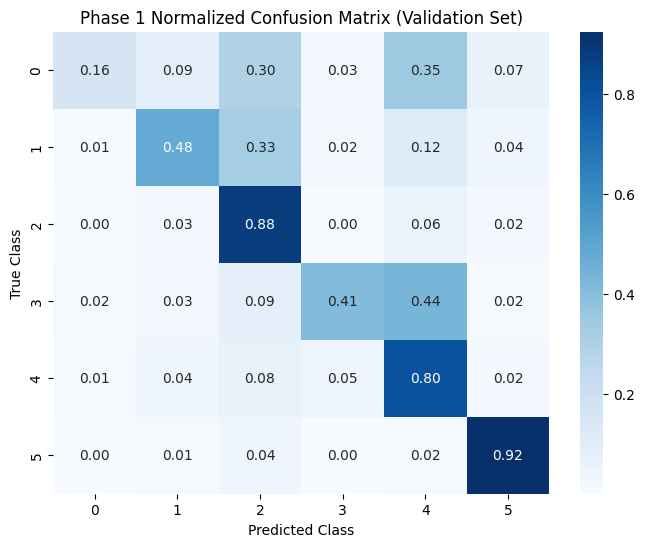

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_p1 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase1.keras')
loss_p1, acc_p1 = model_p1.evaluate(val_ds)
print(f"Phase 1 Validation Accuracy: {acc_p1 * 100:.2f}% | Validation Loss: {loss_p1:.4f}")

preds_p1 = np.argmax(model_p1.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p1, digits=4))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p1, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 1 Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/cm_phase1.png', bbox_inches='tight', dpi=300)
plt.show()

## Phase 2 run 1

111/111 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.7754 - loss: 0.6544
Phase 1 Validation Accuracy: 77.54% | Validation Loss: 0.6544
111/111 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step
              precision    recall  f1-score   support

           0     0.5149    0.2407    0.3281       216
           1     0.7368    0.6792    0.7069       371
           2     0.7973    0.8961    0.8438      1001
           3     0.7543    0.5330    0.6246       409
           4     0.7089    0.8027    0.7529       892
           5     0.9046    0.9347    0.9194       659

    accuracy                         0.7754      3548
   macro avg     0.7361    0.6811    0.6960      3548
weighted avg     0.7665    0.7754    0.7640      3548



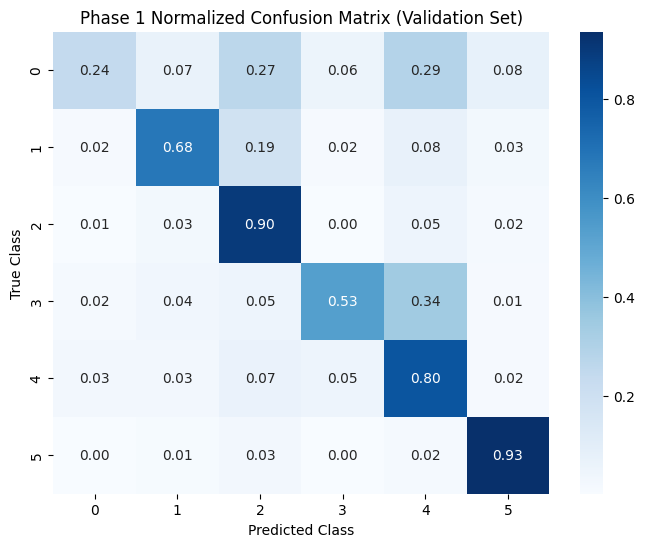

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_p1 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run1.keras')
loss_p1, acc_p1 = model_p1.evaluate(val_ds)
print(f"Phase 1 Validation Accuracy: {acc_p1 * 100:.2f}% | Validation Loss: {loss_p1:.4f}")

preds_p1 = np.argmax(model_p1.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p1, digits=4))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p1, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 1 Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/cm_phase2_run1.png', bbox_inches='tight', dpi=300)
plt.show()

## Phase 2 run 2

111/111 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.7849 - loss: 0.6152
Phase 1 Validation Accuracy: 78.49% | Validation Loss: 0.6152
111/111 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step
              precision    recall  f1-score   support

           0     0.4960    0.2870    0.3636       216
           1     0.7564    0.7197    0.7376       371
           2     0.8282    0.8811    0.8538      1001
           3     0.7422    0.5844    0.6539       409
           4     0.7163    0.8038    0.7575       892
           5     0.9062    0.9378    0.9217       659

    accuracy                         0.7849      3548
   macro avg     0.7409    0.7023    0.7147      3548
weighted avg     0.7769    0.7849    0.7772      3548



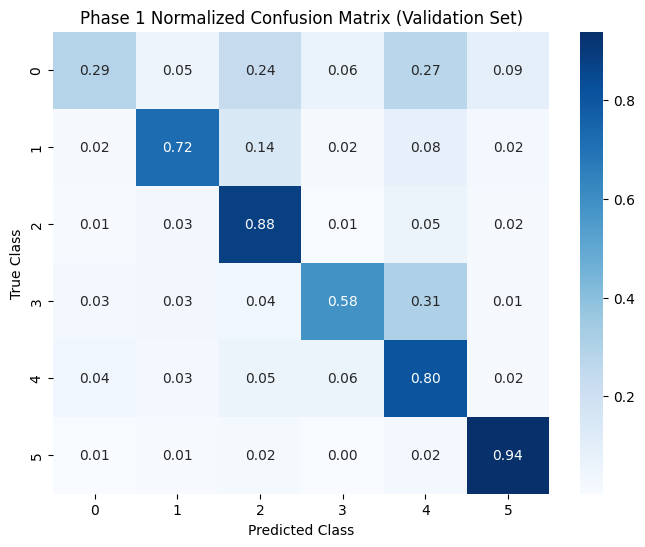

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_p1 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase2_run2.keras')
loss_p1, acc_p1 = model_p1.evaluate(val_ds)
print(f"Phase 1 Validation Accuracy: {acc_p1 * 100:.2f}% | Validation Loss: {loss_p1:.4f}")

preds_p1 = np.argmax(model_p1.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p1, digits=4))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p1, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 1 Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/cm_phase2_run2.png', bbox_inches='tight', dpi=300)
plt.show()

## Phase 3

111/111 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.7869 - loss: 0.6096
Phase 1 Validation Accuracy: 78.69% | Validation Loss: 0.6096
111/111 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step
              precision    recall  f1-score   support

           0     0.4779    0.3009    0.3693       216
           1     0.7111    0.7628    0.7360       371
           2     0.8546    0.8571    0.8559      1001
           3     0.7761    0.6186    0.6884       409
           4     0.7240    0.7971    0.7588       892
           5     0.8860    0.9439    0.9140       659

    accuracy                         0.7869      3548
   macro avg     0.7383    0.7134    0.7204      3548
weighted avg     0.7806    0.7869    0.7808      3548



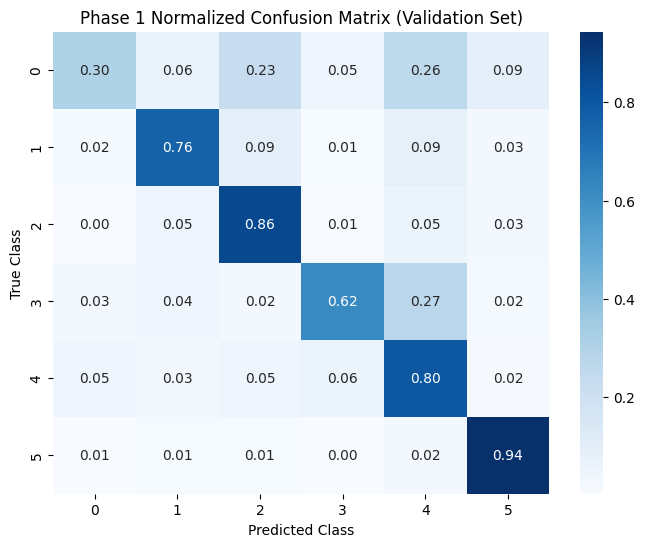

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_p1 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras')
loss_p1, acc_p1 = model_p1.evaluate(val_ds)
print(f"Phase 1 Validation Accuracy: {acc_p1 * 100:.2f}% | Validation Loss: {loss_p1:.4f}")

preds_p1 = np.argmax(model_p1.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p1, digits=4))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p1, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 1 Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals2/cm_phase3.png', bbox_inches='tight', dpi=300)
plt.show()

# GRAD-CAM

In [ ]:
def make_gradcam_heatmap(img_array, model, pred_index=None):

    # Get nested EfficientNetB0
    base_model = model.get_layer("efficientnetb0")

    # Last convolutional layer
    last_conv_layer = base_model.get_layer("top_conv")

    # Model that outputs conv features and EfficientNet output
    conv_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:

        # Forward pass through EfficientNet
        conv_outputs, base_outputs = conv_model(img_array)

        # Classification head
        x = model.get_layer("global_average_pooling2d")(base_outputs)
        x = model.get_layer("dense")(x)
        x = model.get_layer("dropout")(x)
        preds = model.get_layer("dense_1")(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    # Gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients over spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU + normalization
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy()

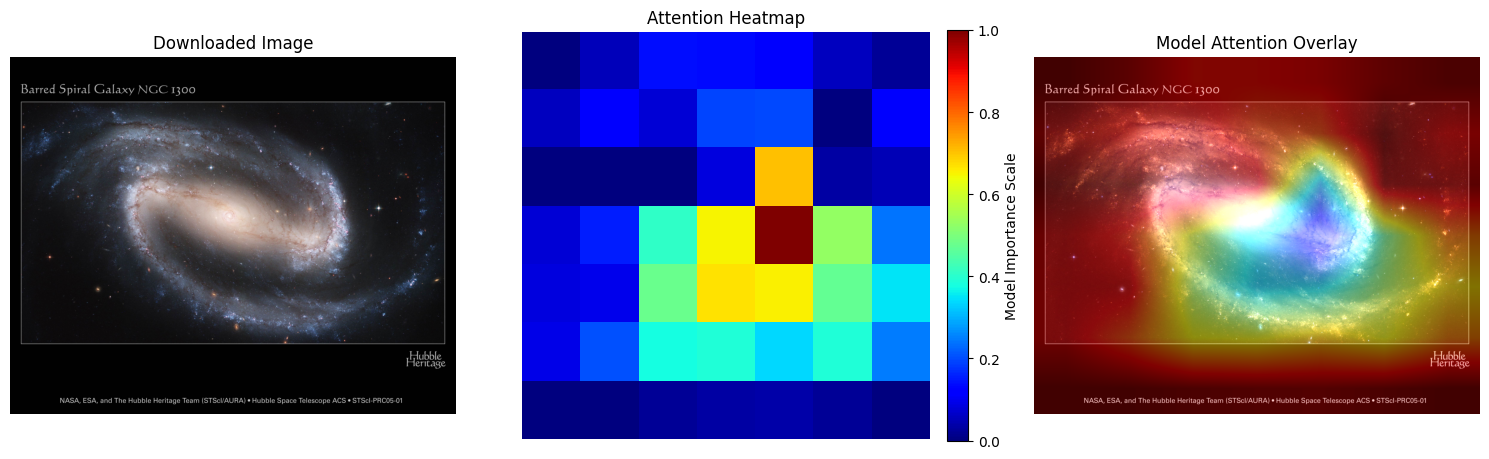

In [ ]:
import urllib.request
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Download image from web URL
url = "https://assets.science.nasa.gov/content/dam/science/missions/hubble/releases/2005/01/STScI-01EVT8DP1YM9FYPF0Y33VY7ANB.tif/jcr:content/renditions/3000x2400.jpg"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img_bgr = cv2.imdecode(arr, -1)

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras"
)

# Save locally to pass to overlay_heatmap
local_path = "downloaded_galaxy.jpg"
cv2.imwrite(local_path, img_bgr)

# 2. Convert & Resize
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))

# 3. Create Tensor & Preprocess
img_tensor = np.expand_dims(img_resized, axis=0)
# img_tensor = img_tensor / 255.0  # Apply if used during training

# 4. Run Grad-CAM
heatmap = make_gradcam_heatmap(img_array=img_tensor, model=model)

# 5. Overlay Heatmap onto Original Image
overlay = overlay_heatmap(heatmap=heatmap, image_path=local_path, alpha=0.5)

# 6. Display with Color Bar
plt.figure(figsize=(15, 5))

# Subplot 1: Raw Original Image
plt.subplot(1, 3, 1)
plt.title("Downloaded Image")
plt.imshow(img_rgb)
plt.axis("off")

# Subplot 2: Activation Heatmap with Colorbar
plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
im = plt.imshow(heatmap, cmap="jet", vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Model Importance Scale")
plt.axis("off")

# Subplot 3: Grad-CAM Overlay
plt.subplot(1, 3, 3)
plt.title("Model Attention Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()